In [ ]:
!rm -rf fraud-detection-pytorch

!git clone https://github.com/deenyzx/fraud-detection-pytorch.git

%cd fraud-detection-pytorch

Cloning into 'fraud-detection-pytorch'...
remote: Enumerating objects: 132, done.
remote: Counting objects: 100% (132/132), done.
remote: Compressing objects: 100% (126/126), done.
remote: Total 132 (delta 57), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (132/132), 34.82 MiB | 17.54 MiB/s, done.
Resolving deltas: 100% (57/57), done.
/content/fraud-detection-pytorch


In [ ]:
!pip install -r requirements.txt

In [ ]:
!python main.py

Using device: cuda

--- Step 1: Preparing Data ---
Extracting and loading: transactions.csv
Successfully engineered 'cvv_match' feature from cardcvv and enteredcvv.
Data ready. Input dimensions (number of features): 6

--- Step 2: Initializing Model ---
AnomalyAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=6, out_features=16, bias=True)
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=16, out_features=8, bias=True)
    (4): ReLU()
    (5): Linear(in_features=8, out_features=4, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=16, bias=True)
    (3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=6, bias=True)
  )
)

--- Step 3: Training Model ---
Training starting...
Epoch 01/20 | Train

Using device: cuda
Extracting and loading: transactions.csv
Successfully engineered 'cvv_match' feature from cardcvv and enteredcvv.
Model and test data successfully loaded.



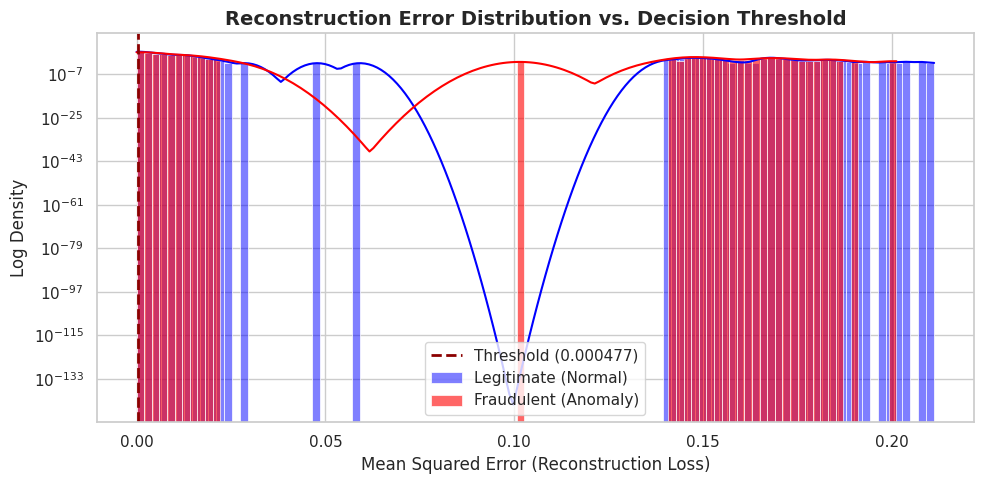

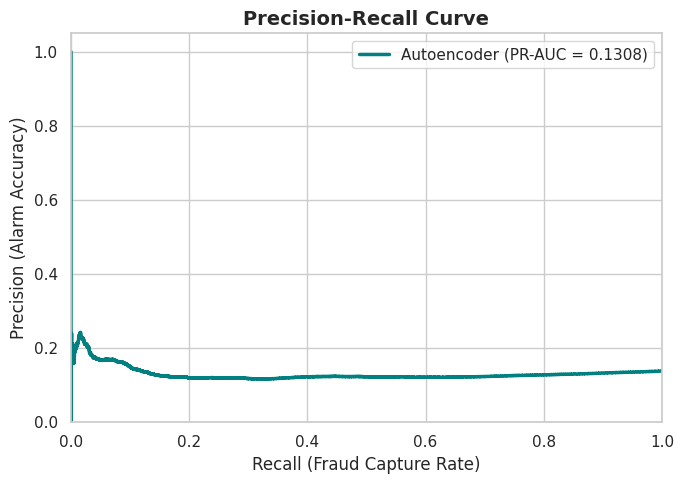

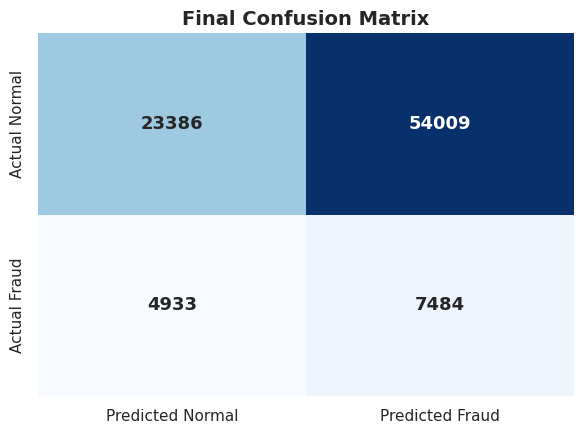

In [ ]:
import sys
import os

# 1. TELL PYTHON WHERE YOUR REPOSITORY IS
# This ensures that 'src' can be imported without any ModuleNotFoundError
repo_path = '/content/fraud-detection-pytorch'  # Double-check if your folder name matches exactly
if repo_path not in sys.path:
    sys.path.append(repo_path)

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc
from src.data_loader import prepare_data
from src.model import AnomalyAutoencoder

# Set professional visualization style
sns.set_theme(style="whitegrid")

# 2. LOAD DATA AND TRAINED MODEL
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Ingest test data using your modular loader
_, _, X_test, y_test, input_dim, scaler = prepare_data('data/creditcard.zip', batch_size=256)

# Initialize and load weights
model = AnomalyAutoencoder(input_dim=input_dim).to(device)
model.load_state_dict(torch.load('models/autoencoder_fraud.pth', map_location=device))
model.eval()
print("Model and test data successfully loaded.\n")

# 3. COMPUTE RECONSTRUCTION ERRORS
X_test_tensor = torch.FloatTensor(X_test).to(device)
with torch.no_grad():
    reconstructed = model(X_test_tensor)

# Calculate Mean Squared Error (MSE) per transaction
mse = torch.mean((X_test_tensor - reconstructed) ** 2, dim=1)
reconstruction_errors = mse.cpu().numpy()

# Set your exact optimal threshold from main.py execution
optimal_threshold = 0.000477
predictions = (reconstruction_errors > optimal_threshold).astype(int)

# ==========================================
# CHART 1: RECONSTRUCTION ERROR DISTRIBUTION
# ==========================================
plt.figure(figsize=(10, 5))
sns.histplot(reconstruction_errors[y_test == 0], bins=100, kde=True, color='blue', label='Legitimate (Normal)', stat='density', alpha=0.5)
sns.histplot(reconstruction_errors[y_test == 1], bins=100, kde=True, color='red', label='Fraudulent (Anomaly)', stat='density', alpha=0.6)
plt.axvline(optimal_threshold, color='darkred', linestyle='--', linewidth=2, label=f'Threshold ({optimal_threshold:.6f})')
plt.yscale('log')  # Log scale helps visualize highly skewed financial data margins
plt.title('Reconstruction Error Distribution vs. Decision Threshold', fontsize=14, fontweight='bold')
plt.xlabel('Mean Squared Error (Reconstruction Loss)', fontsize=12)
plt.ylabel('Log Density', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ==========================================
# CHART 2: PRECISION-RECALL CURVE
# ==========================================
precisions, recalls, _ = precision_recall_curve(y_test, reconstruction_errors)
pr_auc = auc(recalls, precisions)

plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, color='teal', linewidth=2.5, label=f'Autoencoder (PR-AUC = {pr_auc:.4f})')
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.xlabel('Recall (Fraud Capture Rate)', fontsize=12)
plt.ylabel('Precision (Alarm Accuracy)', fontsize=12)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ==========================================
# CHART 3: FINAL CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'],
            cbar=False, annot_kws={"size": 13, "weight": "bold"})
plt.title('Final Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# STEP 6: MANUAL TRANSACTION INFERENCE
# ==========================================
import json as _json
import joblib
import ipywidgets as widgets
from IPython.display import display

# Load saved threshold and scaler
with open('models/threshold.json', 'r') as f:
    OPTIMAL_THRESHOLD = optimal_threshold

scaler_inf = joblib.load('models/scaler.pkl')

# Reload model for inference (reuses input_dim and device from above)
inf_model = AnomalyAutoencoder(input_dim=input_dim).to(device)
inf_model.load_state_dict(torch.load('models/autoencoder_fraud.pth', map_location=device))
inf_model.eval()

# Input widgets
amount  = widgets.FloatText(description='Amount ($):',       value=100.0,  style={'description_width': 'initial'})
avail   = widgets.FloatText(description='Available ($):',    value=5000.0, style={'description_width': 'initial'})
balance = widgets.FloatText(description='Balance ($):',      value=1200.0, style={'description_width': 'initial'})
limit   = widgets.FloatText(description='Credit Limit ($):', value=6000.0, style={'description_width': 'initial'})
present = widgets.Dropdown(description='Card Present:', options=[('Yes', 1), ('No', 0)], style={'description_width': 'initial'})
cvv     = widgets.Dropdown(description='CVV Match:',    options=[('Yes', 1), ('No', 0)], style={'description_width': 'initial'})
button  = widgets.Button(description='Analyse Transaction', button_style='primary')
output  = widgets.Output()

print("=== FRAUD DETECTION — Manual Transaction Entry ===")
display(amount, avail, balance, limit, present, cvv, button, output)

def on_click(_):
    output.clear_output()
    num_vals = scaler_inf.transform([[amount.value, avail.value, balance.value, limit.value]])
    x = torch.FloatTensor([num_vals[0].tolist() + [present.value, cvv.value]]).to(device)

    with torch.no_grad():
        error = torch.mean((x - inf_model(x)) ** 2).item()

    risk = min(100, round((error / (OPTIMAL_THRESHOLD * 2)) * 100, 1))

    if error > OPTIMAL_THRESHOLD * 1.5:
        verdict = '\U0001f6a8 HIGH RISK \u2014 Likely Fraud'
    elif error > OPTIMAL_THRESHOLD:
        verdict = '\u26a0\ufe0f  ELEVATED RISK \u2014 Flag for Review'
    else:
        verdict = '\u2705 LOW RISK \u2014 Likely Legitimate'

    with output:
        print('\n=== TRANSACTION RISK REPORT ===')
        print(f'  Reconstruction Error : {error:.6f}')
        print(f'  Detection Threshold  : {OPTIMAL_THRESHOLD:.6f}')
        print(f'  Risk Score           : {risk} / 100')
        print(f'  Verdict              : {verdict}')
        print('================================')

button.on_click(on_click)

=== FRAUD DETECTION — Manual Transaction Entry ===


FloatText(value=100.0, description='Amount ($):', style=DescriptionStyle(description_width='initial'))

FloatText(value=5000.0, description='Available ($):', style=DescriptionStyle(description_width='initial'))

FloatText(value=1200.0, description='Balance ($):', style=DescriptionStyle(description_width='initial'))

FloatText(value=6000.0, description='Credit Limit ($):', style=DescriptionStyle(description_width='initial'))

Dropdown(description='Card Present:', options=(('Yes', 1), ('No', 0)), style=DescriptionStyle(description_widt…

Dropdown(description='CVV Match:', options=(('Yes', 1), ('No', 0)), style=DescriptionStyle(description_width='…

Button(button_style='primary', description='Analyse Transaction', style=ButtonStyle())

Output()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut